# Common

In [801]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Dict, Any, Callable, List
from scipy.optimize import curve_fit
import sys

np.set_printoptions(linewidth=200)

In [802]:
# --- Класс для параметров стиля ---
@dataclass
class PlotParams:
    """Контейнер для параметров стиля отрисовки."""
    linestyle:  str = "-"
    color:      str = "k"
    linewidth:  float = 1.0
    marker:     Optional[str] = None
    markersize: float = 1.0
    label:      str = ""
    capsize:    float = 3.0
    markevery:  int = 1

# --- Класс-обертка для Matplotlib ---
class Plotter:
    """Класс для инкапсуляции всей логики построения графиков."""
    def __init__(self, title: str, xlabel: str, ylabel: str, figsize: tuple = (16, 9)):
        """Инициализирует фигуру и оси, задает основные подписи."""
        self.fig, self.ax = plt.subplots(figsize=figsize)
        self.ax.set_title(title, fontsize=20, pad=30)
        self.ax.set_xlabel(xlabel, fontsize=18, labelpad=20)
        self.ax.set_ylabel(ylabel, fontsize=18, labelpad=20)

    def add_plot(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        """Отрисовывает точки."""
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
            marker      = params.marker,
            markersize  = params.markersize,
            markevery   = params.markevery
        )

    def add_fit_line(self, x: np.ndarray, y: np.ndarray, params: PlotParams):
        """Отрисовывает сплошную линию (обычно для аппроксимации)."""
        self.ax.plot(
            x, y,
            linestyle   = params.linestyle,
            color       = params.color,
            linewidth   = params.linewidth,
            label       = params.label,
        )

    def add_errorbar_points(self, x: np.ndarray, y: np.ndarray,
                            xerr: Optional[np.ndarray], yerr: Optional[np.ndarray],
                            params: PlotParams):
        """Отрисовывает экспериментальные точки с погрешностями."""
        self.ax.errorbar(
            x, y,
            xerr=xerr,
            yerr=yerr,
            fmt=params.marker,
            color=params.color,
            markersize=params.markersize,
            elinewidth=params.linewidth,
            capsize=params.capsize,
            capthick=params.linewidth,
            markevery=params.markevery,
            label=params.label
        )

    def finalize_and_show(self, save_path: Optional[str] = None):
        """Настраивает финальное оформление, сохраняет и/или показывает график."""
        self.ax.minorticks_on()
        self.ax.grid(True, which='both', linestyle='--', alpha=0.3)
        self.ax.legend(fontsize=14, loc='best', frameon=True, fancybox=True, framealpha=0.9)
        self.ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.5)
        self.ax.tick_params(axis='both', which='minor', length=4, width=1)
        self.fig.tight_layout()

        if save_path:
            self.fig.savefig(save_path)
            print(f"График сохранен в файл: {save_path}")

        plt.show()
        plt.close(self.fig)

In [803]:
def round_with_uncertainty(value: float, uncertainty: float) -> tuple[float, float]:
    """Округляет значение и погрешность по первой значащей цифре погрешности."""
    if uncertainty == 0 or not np.isfinite(uncertainty) or uncertainty < 1e-12:
        return value, uncertainty
    # Определяем порядок для округления на основе погрешности
    order = -int(np.floor(np.log10(abs(uncertainty))))
    return round(value, order), round(uncertainty, order)

def scale_to_scientific(val: float, sigm: float) -> tuple:
    """
    Рассчитывает компоненты для вывода в научном формате (мантисса, порядок и т.д.).
    Возвращает: (округленные val и sigm, мантиссы, порядок, отн. погрешность).
    """
    val_rounded, sigm_rounded = round_with_uncertainty(val, sigm)
    
    # Расчет относительной погрешности
    if np.isclose(val_rounded, 0):
        varepsilon = float('inf')
    else:
        varepsilon = np.abs(sigm_rounded / val_rounded * 100)

    # Определяем порядок числа для научной нотации
    if np.isclose(val_rounded, 0):
        scale_order = 0
    else:
        # Порядок определяется по абсолютному значению округленной величины
        scale_order = -int(np.floor(np.log10(abs(val_rounded))))

    if scale_order != 0:
        latex_value = val_rounded * 10**scale_order
        latex_uncertainty = sigm_rounded * 10**scale_order
    else:
        latex_value = val_rounded
        latex_uncertainty = sigm_rounded

    return val_rounded, sigm_rounded, latex_value, latex_uncertainty, scale_order, varepsilon

def print_parameter_report(val: float, sigm: float, parameter_name: str, unit: str = ""):
    """
    Печатает полный отчет по одному параметру.
    Включает сырые данные, округленные и LaTeX-формат с научной нотацией.
    """
    # Получаем все необходимые компоненты
    val_r, sigm_r, lat_val, lat_sigm, order, eps = scale_to_scientific(val, sigm)
    
    # Печатаем отчет
    print(f"------------ {parameter_name} ------------")
    print(f"Raw value     : {val} ± {sigm}")
    print(f"Rounded value : {val_r} ± {sigm_r}")
    
    # Формируем LaTeX строку с учетом порядка
    if order != 0:
        # f-строка с тройными скобками: {{}} для вывода фигурных скобок в LaTeX
        # и {} для подстановки переменной
        if order > 0:
            print(f"LaTeX: $\\left( {lat_val:.3f} \\pm {lat_sigm:.3f} \\right) \\cdot 10^{{-{order}}}$ \\{unit} $(\\varepsilon = {eps:.2f}\\%)$")
        else:
            print(f"LaTeX: $\\left( {lat_val:.3f} \\pm {lat_sigm:.3f} \\right) \\cdot 10^{{{-order}}}$ \\{unit}  $(\\varepsilon = {eps:.2f}\\%)$")
    else:
        print(f"LaTeX: $\\left( {val_r:.4f} \\pm {sigm_r:.4f} \\right)$ \\{unit},  $(\\varepsilon = {eps:.2f}\\%)$")
    print()

def print_fit_summary(arguments: List[str], popt: np.ndarray, sigm_arr: np.ndarray):
    """
    Печатает сводку по всем результатам аппроксимации.
    """
    print("="*50)
    print("             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ")
    print("="*50)
    for arg, val, sigm in zip(arguments, popt, sigm_arr):
        print_parameter_report(val, sigm, arg)


In [804]:
def load_data(filename: str):
    """Загружает данные из текстового файла."""
    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1]

def calculate_errors(xdata: np.ndarray, ydata: np.ndarray, config: Dict[str, Any]) -> tuple[np.ndarray, np.ndarray]:
    """
    Гибко вычисляет массивы погрешностей для x и y на основе конфигурационного словаря.
    """
    err_type = config.get('type')
    xerr, yerr = None, None # По умолчанию погрешностей нет

    if err_type == 'absolute':
        xerr = np.full_like(xdata, config.get('x_val', 0))
        yerr = np.full_like(ydata, config.get('y_val', 0))
    elif err_type == 'percent':
        xerr = config.get('x_val', 0) * xdata
        yerr = config.get('y_val', 0) * ydata
    elif err_type == 'custom':
        xerr = config.get('x_err_custom')
        yerr = config.get('y_err_custom')
        
    # Если какой-то из массивов не был создан, заменяем его на массив нулей
    if xerr is None:
        xerr = np.zeros_like(xdata)
    if yerr is None:
        yerr = np.zeros_like(ydata)
        
    return xerr, yerr

In [805]:
def load_data(filename: str):
    """Загружает данные из текстового файла с двумя колонками."""
    data = np.loadtxt(filename)
    return data[:, 0], data[:, 1]

# --- 1. Загрузка и расчет фона ---
filename_background = 'background.txt'
Nf_values, dNf_values = load_data(filename_background)

# Расчет взвешенного среднего фона и его погрешности
weights_bg = 1 / np.square(dNf_values)
mean_Nf_weighted = np.average(Nf_values, weights=weights_bg)
error_mean_Nf = 1 / np.sqrt(np.sum(weights_bg))

print("="*50); print("РАСЧЕТ ФОНА"); print("="*50)
print_parameter_report(mean_Nf_weighted, error_mean_Nf, "N_фон", "1/c")

# --- 2. Загрузка данных спектра и вычитание фона ---
filename_data = 'data.txt'
I_data, N_raw_data = load_data(filename_data)

# Вычитаем фон
N_net_data = np.maximum(0, N_raw_data - mean_Nf_weighted)

N_raw_data_error = np.sqrt(100 * N_raw_data) / 100

error_N_net = np.sqrt(N_raw_data_error**2 + error_mean_Nf**2)

РАСЧЕТ ФОНА
------------ N_фон ------------
Raw value     : 1.6321797327811935 ± 0.06385023336758841
Rounded value : 1.63 ± 0.06
LaTeX: $\left( 1.6300 \pm 0.0600 \right)$ \1/c,  $(\varepsilon = 3.68\%)$



# Settings

In [806]:
# arguments = ['a']
# def func_ax(x, a):
#     return a * x

# arguments = ['a', 'b']
# def func_axpb(x, a, b):
#     return a * x + b

# arguments = ['y0', 'C', 'x0']
# def func_gartman(x, y0, C, x0):
#     return y0 + C / (x - x0)

# arguments = ['a', 'b', 'c', 'd']
# def polinomial_func(x, a, b, c, d):
#     return a * x**3 + b * x**2 + c * x + d

# arguments = ['y0', 'power', 'bias']
# def exponential_func(x, y0, power, bias):
#     return y0 * np.exp(power * x) + bias

arguments = ['C1', 'p_max', 'amp', 'mean_p', 'sigma_p', 'bias', 'k', 'bias_under_root']
def beta_spectrum(p, C, p_max, bias, bias_under_root):
    energy_term = np.sqrt(p_max**2 + bias_under_root) - np.sqrt(p**2 + bias_under_root)
    energy_term[p > p_max] = 0 # Обнуляем значения за границей
    return bias + C * p**2 * energy_term**2
def gaussian(p, amp, mean_p, sigma_p):
    return amp * np.exp(-((p - mean_p) / sigma_p)**2 / 2)
def total_model(I, C1, p_max, amp, mean_p, sigma_p, bias, k, bias_under_root):
    p = k * I
    beta  = beta_spectrum(p, C1, p_max, bias, bias_under_root)
    gauss = gaussian(p, amp, mean_p, sigma_p)
    
    return beta + gauss

In [807]:
func = total_model

# Changable parameters

In [808]:
# # (0 --- np.inf)
# error_config = \
# {
#     'type': 'absolute', 
#     'x_val': 0.01, 
#     'y_val': 0.2
# }

# # (0 --- 1)
# error_config = \
# {
#     'type': 'percent', 
#     'x_val': 0.05, 
#     'y_val': 0.1
# }

# User errors
error_config = \
{
    'type': 'custom', 
    'x_val': np.full_like(I_data, 0.02), 
    'y_val': error_N_net,
}

In [809]:
initial_guess = [1.0, 3.5, 2.0, 3.55, 0.1, 2, 1, 1]

# Run

In [810]:
# 2. Расчет погрешностей
xerr, yerr = calculate_errors(I_data, N_net_data, error_config)

# 3. Аппроксимация
popt, pcov = curve_fit(func, I_data, N_net_data, initial_guess, sigma=error_N_net, absolute_sigma=True,)

# 4. Вывод результатов
print_fit_summary(arguments, popt, np.sqrt(np.diag(pcov)))

# Извлечем нужные параметры для дальнейших расчетов
amp_fit, mean_p_fit, sigma_p_fit, k_fit = popt[2], popt[3], popt[4], popt[6]


             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ
------------ C1 ------------
Raw value     : 1494.9481735455731 ± 4119130.0467895954
Rounded value : 0.0 ± 4000000.0
LaTeX: $\left( 0.0000 \pm 4000000.0000 \right)$ \,  $(\varepsilon = inf\%)$

------------ p_max ------------
Raw value     : 3.0145729125699843 ± 1187.2206435696883
Rounded value : 0.0 ± 1000.0
LaTeX: $\left( 0.0000 \pm 1000.0000 \right)$ \,  $(\varepsilon = inf\%)$

------------ amp ------------
Raw value     : 4.220875857702753 ± 0.16185448057651716
Rounded value : 4.2 ± 0.2
LaTeX: $\left( 4.2000 \pm 0.2000 \right)$ \,  $(\varepsilon = 4.76\%)$

------------ mean_p ------------
Raw value     : 2.923230367438193 ± 1151.1675404781581
Rounded value : 0.0 ± 1000.0
LaTeX: $\left( 0.0000 \pm 1000.0000 \right)$ \,  $(\varepsilon = inf\%)$

------------ sigma_p ------------
Raw value     : 0.16721751091349282 ± 65.84682212136309
Rounded value : 0.0 ± 70.0
LaTeX: $\left( 0.0000 \pm 70.0000 \right)$ \,  $(\varepsilon = inf\%)$

------------ 

In [811]:
# --- Физические константы ---
m_e_c2_MeV = 0.511  # Энергия покоя электрона в МэВ
T_k_MeV = 0.624     # Кинетическая энергия конверсионных электронов для 137Cs в МэВ
c = 3e8

In [819]:
# --- 1. Калибровка ---
# Рассчитываем импульс, соответствующий энергии T_k
p_k_MeV_c = np.sqrt(T_k_MeV**2 + 2 * T_k_MeV * m_e_c2_MeV)

p_k_MeV_c
p_k_keV_slash_c = p_k_MeV_c / c * 1e3

p_k_keV_slash_c

3.3782046513890576e-06

In [813]:
# Наш модельный импульс p_model = k*I. Пик находится при p_model = mean_p_fit.
# Физический импульс p_phys = A * p_model, где A - калибровочная константа.
# В точке пика: p_k_MeV_c = A * mean_p_fit.
# I_peak = 3.6248069375395326
I_peak = mean_p_fit / k_fit

A_calib = p_k_keV_slash_c / I_peak
print("="*50)
print("КАЛИБРОВКА")
print("="*50)
print(f"Калибровочный коэффициент A: {A_calib * c}/c (кэВ/c/A)")

КАЛИБРОВКА
Калибровочный коэффициент A: 278.62403501932306/c (кэВ/c/A)


In [814]:
# Функции для пересчета из тока в физические величины
def current_to_momentum_keV(I, A_calib):
    return A_calib * I

def current_to_energy_keV(I, A_calib):
    p_k_keV_slash_c = current_to_momentum_keV(I, A_calib)
    return np.sqrt((p_k_keV_slash_c*c)**2 + (m_e_c2_MeV*1e3)**2) - (m_e_c2_MeV*1e3)

In [815]:
current_to_energy_keV(3.0, A_calib)

468.6954506447605

In [816]:
markevery_i = 1
# --- Стили для графика ---
plot_args_dict = \
{
    "Fitted":     PlotParams(linestyle="--", color="black", linewidth=1, label='Аппроксимация'),
    "Error_bars": PlotParams(color="black", linewidth=2, marker="*", markersize=14, capsize=3, label="Экспериментальные данные"),
    "Dots":       PlotParams(color="black", marker="*", markersize=130, markevery = markevery_i, label = "Dots"),
}

График сохранен в файл: spectrum_plot.pdf


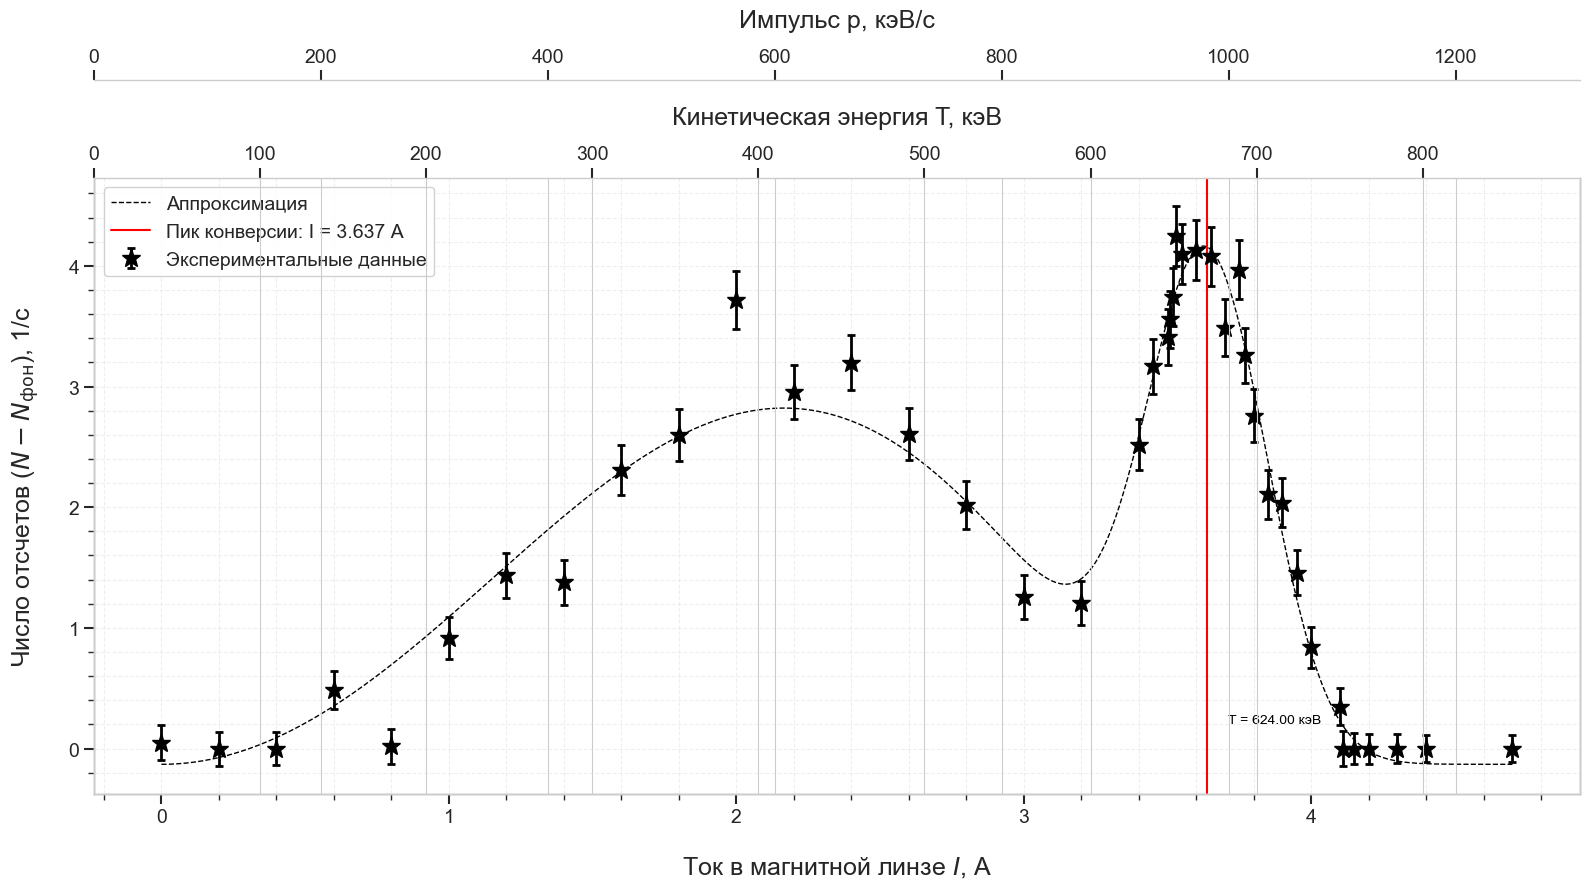

In [817]:
from scipy.optimize import minimize_scalar

# --- 2. Построение графика ---
plotter = Plotter(
    title=None,
    xlabel=r'Ток в магнитной линзе $I$, А',
    ylabel=r'Число отсчетов ($N - N_\text{фон}$), 1/c'
)

# Добавляем экспериментальные точки
plotter.add_errorbar_points(I_data, N_net_data, xerr=None, yerr=error_N_net, params=plot_args_dict['Error_bars'])

# Добавляем кривую аппроксимации
I_smooth = np.linspace(I_data.min(), I_data.max(), 500)
N_fit = total_model(I_smooth, *popt)

plotter.add_fit_line(I_smooth, N_fit, params=plot_args_dict['Fitted'])

# --- 3. Создание дополнительных осей (энергии и импульса) ---

# Чтобы оси не перекрывались, делаем верхнюю рамку основной оси невидимой
plotter.ax.spines['top'].set_visible(False)

# Получаем пределы по основной оси тока, чтобы согласовать остальные оси
min_I, max_I = I_data.min(), I_data.max()

# --- Ось ЭНЕРГИИ (первая дополнительная, наверху) ---
ax2_energy = plotter.ax.twiny()
ax2_energy.set_xlabel("Кинетическая энергия T, кэВ", fontsize=18, labelpad=15)
min_E, max_E = current_to_energy_keV(min_I, A_calib), current_to_energy_keV(max_I, A_calib)
ax2_energy.set_xlim(min_E, max_E)
ax2_energy.tick_params(axis='x', which='major', labelsize=14, length=7, width=1.5)

# --- Ось ИМПУЛЬСА (вторая дополнительная, над энергией) ---
ax3_momentum = plotter.ax.twiny()
# Смещаем ось импульса еще выше, чтобы она не накладывалась на ось энергии
# 'outward' означает "наружу" от графика, 60 - это смещение в пунктах (points)
ax3_momentum.spines['top'].set_position(('outward', 70))
ax3_momentum.set_xlabel("Импульс p, кэВ/c", fontsize=18, labelpad=15)

# Рассчитываем и устанавливаем пределы для оси импульса
min_p, max_p = c * current_to_momentum_keV(min_I, A_calib), c * current_to_momentum_keV(max_I, A_calib)
ax3_momentum.set_xlim(min_p, max_p)
ax3_momentum.tick_params(axis='x', which='major', labelsize=14, length=7, width=1.5)

# --- 4. Добавление вертикальной линии для пика конверсии ---

# Рисуем вертикальную линию на основной оси графика
plotter.ax.axvline(
    x=I_peak,
    color='red',
    linestyle='-',
    linewidth=1.5,
    label=f'Пик конверсии: I = {I_peak:.3f} А' # Эта метка появится в легенде
)

# (Опционально) Добавляем текстовую аннотацию рядом с линией
y_lims = plotter.ax.get_ylim()
plotter.ax.text(
    x=I_peak * 1.02, # С небольшим смещением вправо от линии
    y=y_lims[1] * 0.05,        # На середине высоты графика
    s=f'T = {T_k_MeV*1000:.2f} кэВ', # Текст аннотации
    rotation=0,              # Поворачиваем текст вертикально
    verticalalignment='center',
    color='black'
)

# Финализируем и показываем график
plotter.finalize_and_show("spectrum_plot.pdf")


C:\Users\Skif\AppData\Local\Temp\ipykernel_19620\3727116555.py:17: RuntimeWarning: divide by zero encountered in divide
  Y_fermi = np.sqrt(N_fermi / (p_fermi**2))
c:\Users\Skif\anaconda3\Lib\site-packages\matplotlib\axes\_axes.py:3680: RuntimeWarning: invalid value encountered in add
  low, high = dep + np.vstack([-(1 - lolims), 1 - uplims]) * err


             РЕЗУЛЬТАТЫ АППРОКСИМАЦИИ
------------ a ------------
Raw value     : -1923.6119829067914 ± 187.91261981325636
Rounded value : -1900.0 ± 200.0
LaTeX: $\left( -1.900 \pm 0.200 \right) \cdot 10^{3}$ \  $(\varepsilon = 10.53\%)$

------------ b ------------
Raw value     : 1373453.7089061916 ± 69273.65992146728
Rounded value : 1370000.0 ± 70000.0
LaTeX: $\left( 1.370 \pm 0.070 \right) \cdot 10^{6}$ \  $(\varepsilon = 5.11\%)$

АНАЛИЗ ГРАФИКА ФЕРМИ
------------ T_max ------------
Raw value     : 713.9972723764959 ± 78.49675956049131
Rounded value : 710.0 ± 80.0
LaTeX: $\left( 7.100 \pm 0.800 \right) \cdot 10^{2}$ \кэВ  $(\varepsilon = 11.27\%)$

График сохранен в файл: fermi_plot.pdf


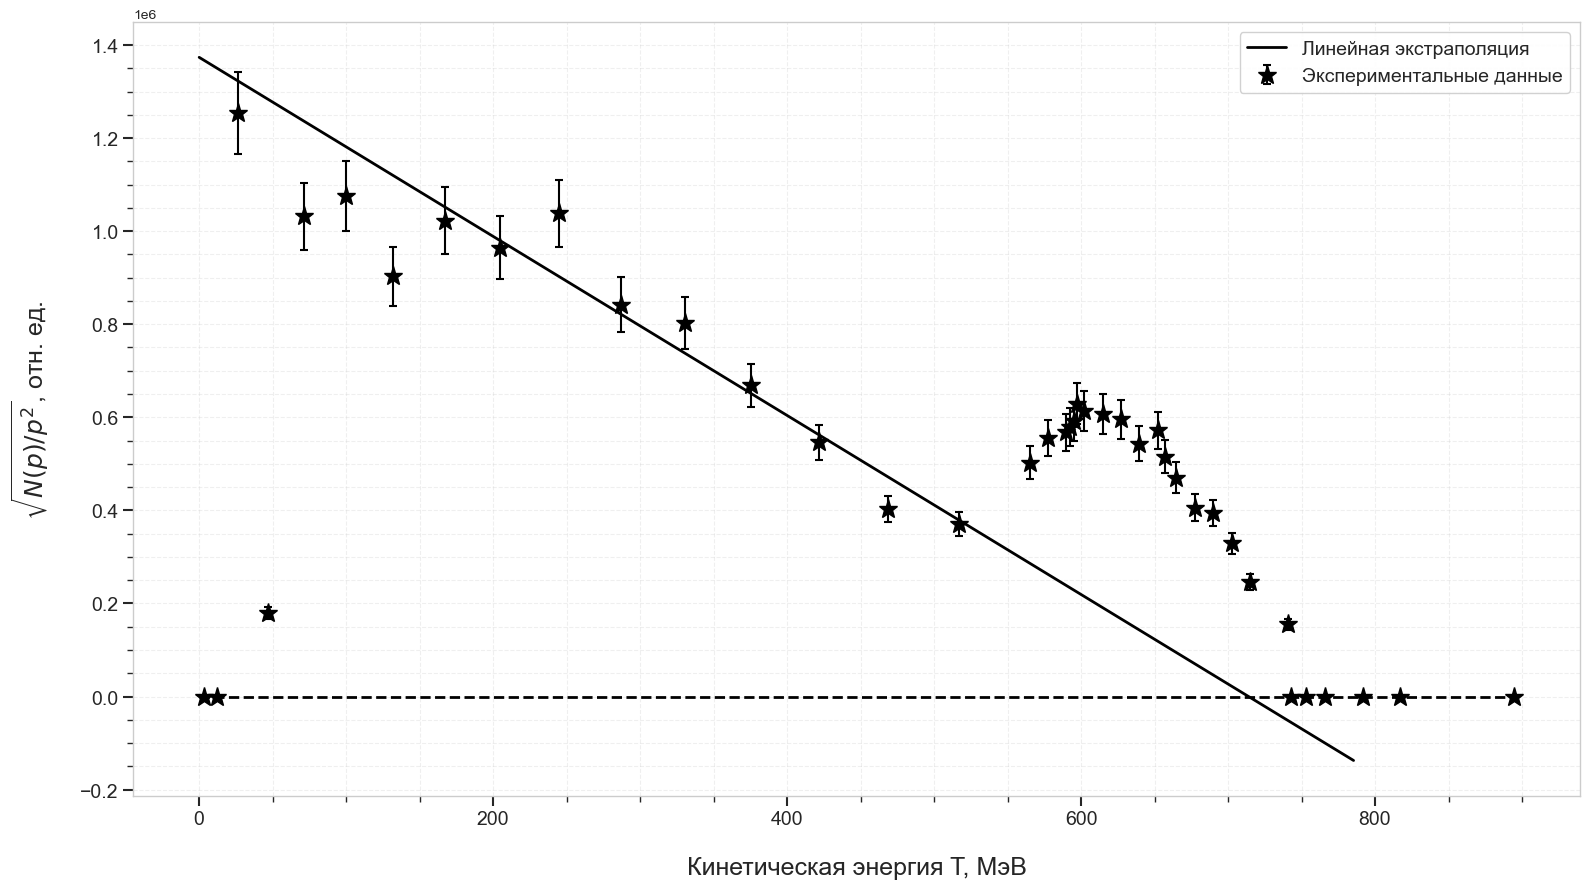

In [820]:
# --- 1. Подготовка данных для графика Ферми ---
# Выбираем область для аппроксимации: правый склон бета-спектра, после пика конверсии
# и до затухания. Подберем диапазон по току.

mask = np.asarray([False for _ in range(len(I_data))])
mask[5:17] = True

I_fermi = I_data
N_fermi = N_net_data
err_N_fermi = error_N_net

# Пересчитываем в физические величины
T_fermi = current_to_energy_keV(I_fermi, A_calib)
p_fermi = current_to_momentum_keV(I_fermi, A_calib)

# Вычисляем величину для оси Y графика Ферми
Y_fermi = np.sqrt(N_fermi / (p_fermi**2))

# Распространение погрешности для Y_fermi
# σ(Y) ≈ |∂Y/∂N| * σ(N) = (1 / (2 * p * sqrt(N))) * σ(N)
err_Y_fermi = (1 / (2 * p_fermi[mask] * np.sqrt(N_fermi[mask]))) * err_N_fermi[mask]

# --- 2. Линейная аппроксимация ---
def linear_func(x, m, c):
    return m * x + c

popt_fermi, pcov_fermi = curve_fit(linear_func, np.array(T_fermi)[mask], np.array(Y_fermi)[mask], sigma=np.array(err_Y_fermi))
m_fermi, c_fermi = popt_fermi
err_m_fermi, err_c_fermi = np.sqrt(np.diag(pcov_fermi))

arg_names = ['a', 'b']
print_fit_summary(arg_names, popt_fermi, np.sqrt(np.diag(pcov_fermi)))

# --- 3. Находим T_max (точка пересечения с осью X) ---
T_max = -c_fermi / m_fermi

# Погрешность для T_max (как для частного)
error_T_max = abs(T_max) * np.sqrt((err_m_fermi/m_fermi)**2 + (err_c_fermi/c_fermi)**2)

print("="*50); print("АНАЛИЗ ГРАФИКА ФЕРМИ"); print("="*50)
print_parameter_report(T_max, error_T_max, "T_max", "кэВ")

# --- 4. Построение графика Ферми ---
plotter_fermi = Plotter(
    title=None,
    xlabel='Кинетическая энергия T, МэВ',
    ylabel=r'$\sqrt{N(p) / p^2}$, отн. ед.'
)

# Экспериментальные точки
plot_params_fermi_data = PlotParams(marker="*", linestyle="", color="black", markersize=14,
                                    linewidth=1.5, label="Экспериментальные данные")
plotter_fermi.add_errorbar_points(T_fermi, Y_fermi, xerr=None, yerr=Y_fermi*0.07, params=plot_params_fermi_data)

# Линия аппроксимации с экстраполяцией
T_fit_range = np.linspace(0, T_max * 1.1, 100)
Y_fit_fermi = linear_func(T_fit_range, m_fermi, c_fermi)
plot_params_fermi_fit = PlotParams(linestyle="-", color="black", linewidth=2.0, label="Линейная экстраполяция")
plotter_fermi.add_fit_line(T_fit_range, Y_fit_fermi, params=plot_params_fermi_fit)

plot_params_zero_lvl = PlotParams(linestyle="--", color="black", linewidth=2.0, label=None)
plotter_fermi.add_fit_line(T_fermi, np.full_like(Y_fermi, 0), params=plot_params_zero_lvl)

plotter_fermi.finalize_and_show("fermi_plot.pdf")
